# 02 — Statistiques descriptives & Visualisations

Analyse des données CNAV/CARSAT sur les retraités du régime général.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from src.visualize import plot_time_series, plot_gender_gap, save_fig
%matplotlib inline

## 1. Effectifs retraités au 31/12 — Total et par genre

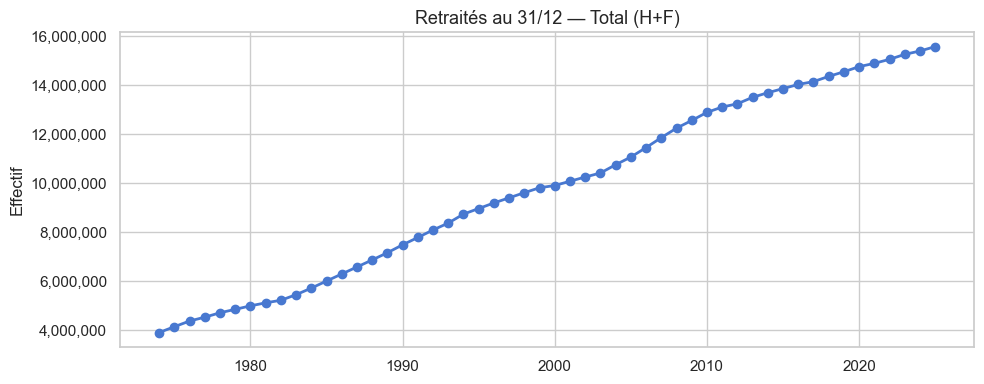

In [2]:
df_genre = pd.read_parquet('../data/processed/nombre-de-retraites-au-31-decembre-par-genre.parquet')

# Total H+F
df_total = df_genre.groupby('annees_transfo')['nombre_de_retraites'].sum().sort_index()
fig = plot_time_series(df_total, title='Retraités au 31/12 — Total (H+F)', ylabel='Effectif')
save_fig(fig, 'effectifs_total')
plt.show()

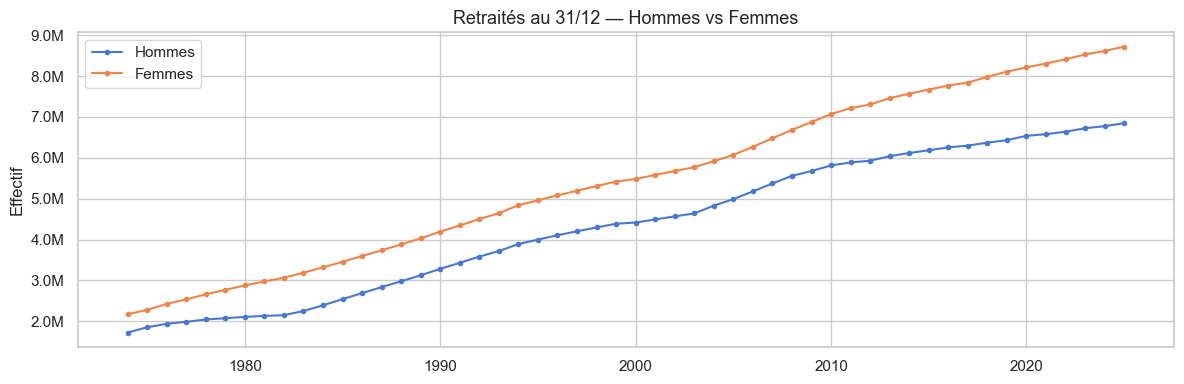

Dernier point (2025) : 15,567,450 retraités


In [3]:
# Hommes vs Femmes
df_h = df_genre[df_genre['sexe'] == 'Hommes'].set_index('annees_transfo')['nombre_de_retraites'].sort_index()
df_f = df_genre[df_genre['sexe'] == 'Femmes'].set_index('annees_transfo')['nombre_de_retraites'].sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_h.index, df_h.values, label='Hommes', marker='o', markersize=3)
ax.plot(df_f.index, df_f.values, label='Femmes', marker='o', markersize=3)
ax.set_title('Retraités au 31/12 — Hommes vs Femmes', fontsize=13)
ax.set_ylabel('Effectif')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
save_fig(fig, 'effectifs_genre')
plt.show()
print(f'Dernier point ({df_total.index[-1]}) : {df_total.iloc[-1]:,.0f} retraités')

## 2. Montant moyen mensuel de pension au 31/12

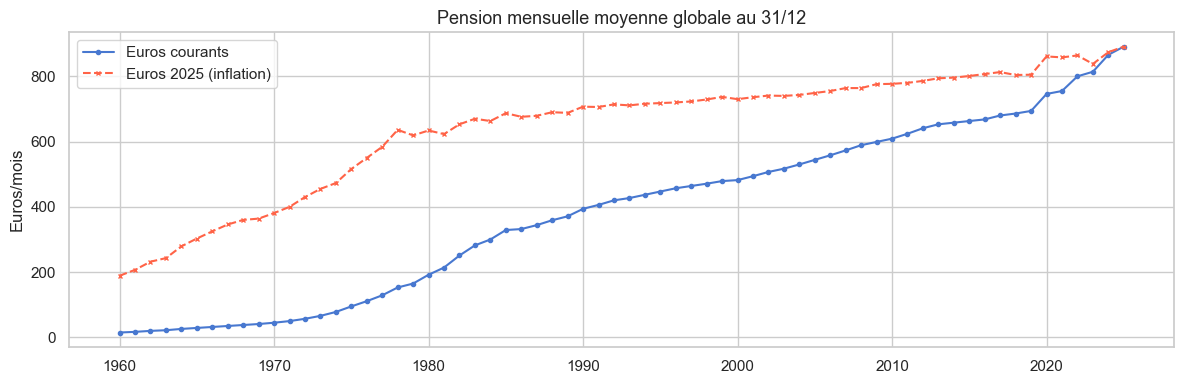

In [4]:
df_montant = pd.read_parquet('../data/processed/montant-global-de-la-retraite-au-31-decembre.parquet')
df_montant = df_montant.dropna(subset=['annees_normees']).sort_values('annees_normees')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_montant['annees_normees'],
        df_montant['montant_mensuel_moyen_au_31_decembre_de_la_retraite_globale_en_euros'],
        label='Euros courants', marker='o', markersize=3)
ax.plot(df_montant['annees_normees'],
        df_montant['montant_equivalent_en_2025_montant_en_euros_corrige_de_l_inflation'],
        label='Euros 2025 (inflation)', marker='x', markersize=3, linestyle='--', color='tomato')
ax.set_title('Pension mensuelle moyenne globale au 31/12', fontsize=13)
ax.set_ylabel('Euros/mois')
ax.legend()
plt.tight_layout()
save_fig(fig, 'montant_moyen_global')
plt.show()

## 3. Écart H/F — montant global attribué

In [5]:
df_hf = pd.read_parquet('../data/processed/montant-global-de-la-retraite-attribuee-selon-le-genre.parquet')
df_hf['annees'] = pd.to_numeric(df_hf['annees'], errors='coerce')
df_hf = df_hf.dropna(subset=['annees']).sort_values('annees')

df_pivot = df_hf.pivot_table(index='annees', columns='genre',
                              values='montant_global_mensuel_moyen_attribue_en_euros')

fig = plot_gender_gap(df_pivot.reset_index(), 'annees', 'Hommes', 'Femmes',
                      title='Montant mensuel moyen attribué — Écart H/F (€ courants)')
fig.show()

# Ratio
df_pivot['ratio_f_h'] = (df_pivot['Femmes'] / df_pivot['Hommes'] * 100).round(1)
print('\nRatio Femmes/Hommes (%) :')
print(df_pivot['ratio_f_h'].tail(10).to_string())


Ratio Femmes/Hommes (%) :
annees
2014.0    82.4
2015.0    81.4
2016.0    82.8
2017.0    81.9
2018.0    79.1
2019.0    79.1
2021.0    76.3
2022.0    76.7
2023.0    77.3
2024.0    76.4


## 4. Âge moyen à l'attribution

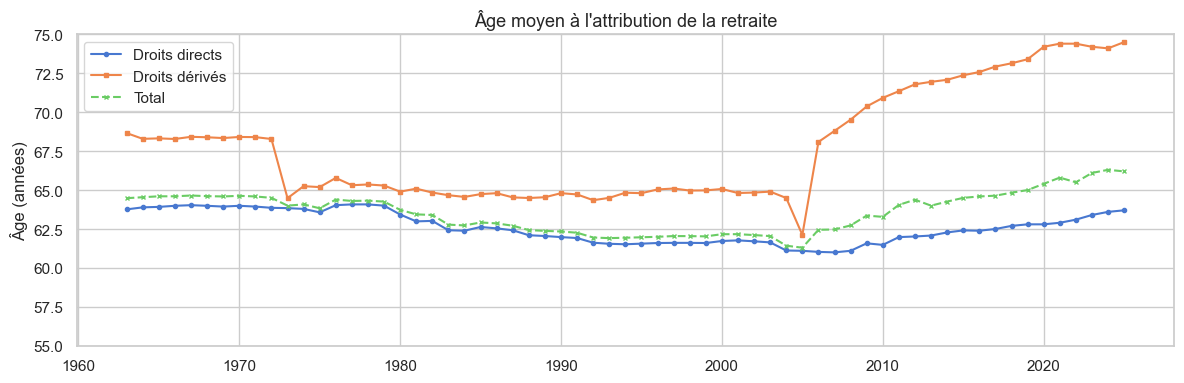

In [6]:
df_age = pd.read_parquet('../data/processed/age-moyen-a-lattribution.parquet')
df_age = df_age.dropna(subset=['annee']).sort_values('annee')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_age['annee'], df_age['droits_directs'], label='Droits directs', marker='o', markersize=3)
ax.plot(df_age['annee'], df_age['droits_derives_1'], label='Droits dérivés', marker='s', markersize=3)
ax.plot(df_age['annee'], df_age['total'], label='Total', marker='x', markersize=3, linestyle='--')
ax.set_title("Âge moyen à l'attribution de la retraite", fontsize=13)
ax.set_ylabel('Âge (années)')
ax.set_ylim(55, 75)
ax.legend()
plt.tight_layout()
save_fig(fig, 'age_moyen_attribution')
plt.show()

## 5. Durée d'assurance moyenne (en trimestres)

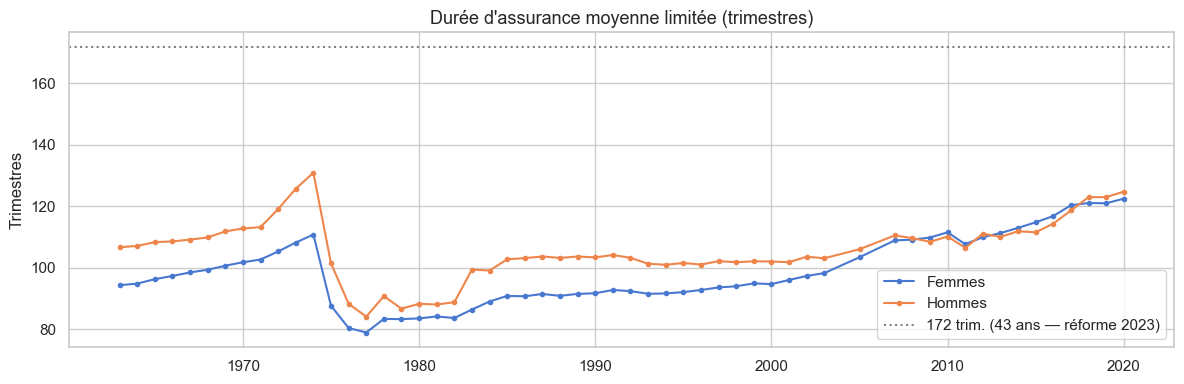

In [7]:
df_dur = pd.read_parquet('../data/processed/durees-moyennes-dassurance-limitees-et-non-limitees.parquet')
df_dur['annees'] = pd.to_numeric(df_dur['annees'], errors='coerce')
df_dur = df_dur.dropna(subset=['annees', 'durees_moyennes_d_assurance_en_trimestres']).sort_values('annees')

fig, ax = plt.subplots(figsize=(12, 4))
for sexe, grp in df_dur.groupby('sexe'):
    ax.plot(grp['annees'], grp['durees_moyennes_d_assurance_en_trimestres'],
            label=sexe, marker='o', markersize=3)
ax.axhline(y=172, color='gray', linestyle=':', label='172 trim. (43 ans — réforme 2023)')
ax.set_title("Durée d'assurance moyenne limitée (trimestres)", fontsize=13)
ax.set_ylabel('Trimestres')
ax.legend()
plt.tight_layout()
save_fig(fig, 'duree_assurance')
plt.show()

## 6. Attributions par type de droit

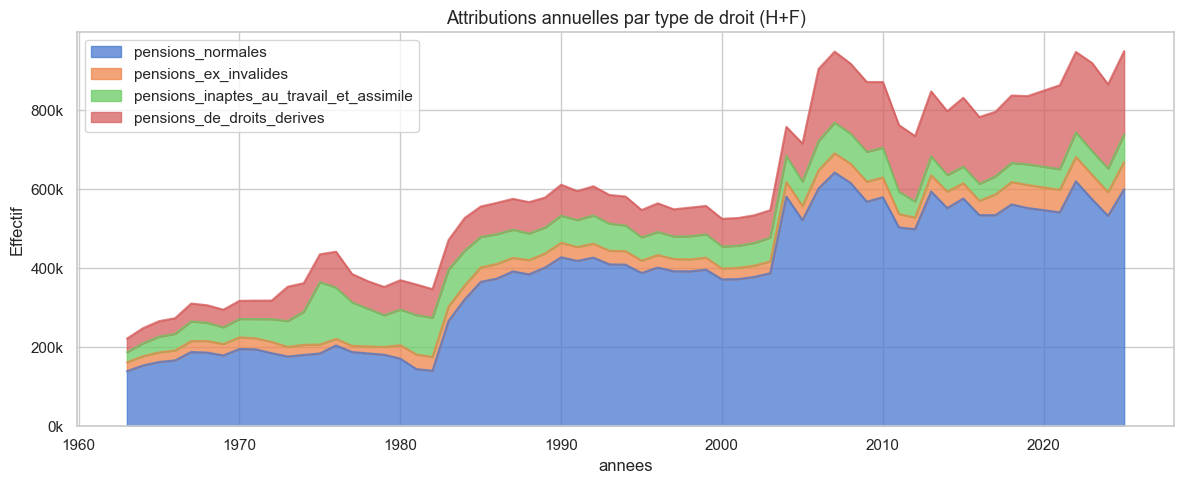

In [8]:
df_type = pd.read_parquet('../data/processed/attributions-de-lannee-selon-le-type-de-droits.parquet')
df_type['annees'] = pd.to_numeric(df_type['annees'], errors='coerce')
df_type = df_type.dropna(subset=['annees'])

# Total H+F
df_agg = df_type.groupby('annees')[[
    'pensions_normales', 'pensions_ex_invalides',
    'pensions_inaptes_au_travail_et_assimile',
    'pensions_de_droits_derives'
]].sum().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
df_agg.plot(kind='area', stacked=True, ax=ax, alpha=0.75)
ax.set_title('Attributions annuelles par type de droit (H+F)', fontsize=13)
ax.set_ylabel('Effectif')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
save_fig(fig, 'attributions_type_droit')
plt.show()